In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from itertools import combinations

In [ ]:
df = pd.read_excel("Task3_Customer_Segmentation_Dataset.xlsx")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 17)


,Transaction_ID,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Order_Month,Order_Year,Order_Month_Name,Customer_Segment
0,TXN0001,ORD100002,2025-02-25,CUST5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025-02,2025,February,Cluster 0
1,TXN0002,ORD100003,2025-10-14,CUST3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025-10,2025,October,Cluster 0
2,TXN0003,ORD100004,2025-05-13,CUST8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025-05,2025,May,Cluster 1
3,TXN0004,ORD100005,2025-12-02,CUST2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025-12,2025,December,Cluster 2
4,TXN0005,ORD100006,2025-11-20,CUST4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025-11,2025,November,Cluster 1


In [ ]:
print(df.info())
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
print(df["Customer_Segment"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction_ID    1000 non-null   object        
 1   Order_ID          1000 non-null   object        
 2   Order_Date        1000 non-null   datetime64[ns]
 3   Customer_ID       1000 non-null   object        
 4   Customer_Name     1000 non-null   object        
 5   Age               1000 non-null   int64         
 6   Gender            1000 non-null   object        
 7   City              1000 non-null   object        
 8   Product           1000 non-null   object        
 9   Category          1000 non-null   object        
 10  Quantity          1000 non-null   int64         
 11  Unit_Price        1000 non-null   float64       
 12  Total_Sales       1000 non-null   float64       
 13  Order_Month       1000 non-null   object        
 14  Order_Year        1000 no

In [ ]:
customer_data = df.groupby("Customer_ID").agg(
    Total_Spending=("Total_Sales", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Number_of_Orders=("Order_ID", "nunique"),
    Average_Age=("Age", "mean"),
    Customer_Segment=("Customer_Segment", "first")
).reset_index()

In [ ]:
customer_data["Average_Order_Value"] = (
    customer_data["Total_Spending"] /
    customer_data["Number_of_Orders"]
)
customer_data.head()
print(customer_data.shape)

(947, 7)


In [ ]:
customer_data["Customer_Segment"].value_counts()

,count
Customer_Segment,
Cluster 0,613
Cluster 1,282
Cluster 2,52


In [ ]:
segment_summary = customer_data.groupby("Customer_Segment").agg(
    Customers=("Customer_ID", "count"),
    Total_Spending=("Total_Spending", "sum"),
    Average_Spending=("Total_Spending", "mean"),
    Median_Spending=("Total_Spending", "median"),
    Spending_Std=("Total_Spending", "std"),
    Average_Orders=("Number_of_Orders", "mean"),
    Average_Order_Value=("Average_Order_Value", "mean")
).round(2)

segment_summary

,Customers,Total_Spending,Average_Spending,Median_Spending,Spending_Std,Average_Orders,Average_Order_Value
Customer_Segment,,,,,,,
Cluster 0,613,45405069.44,74070.26,70470.99,49418.52,1.00,74070.26
Cluster 1,282,77820568.67,275959.46,256721.98,85228.79,1.00,275959.46
Cluster 2,52,16173801.54,311034.64,282543.37,186810.35,2.02,154135.29


In [ ]:
segment_summary.to_excel(
    "Task4_Segment_Statistical_Summary.xlsx"
)

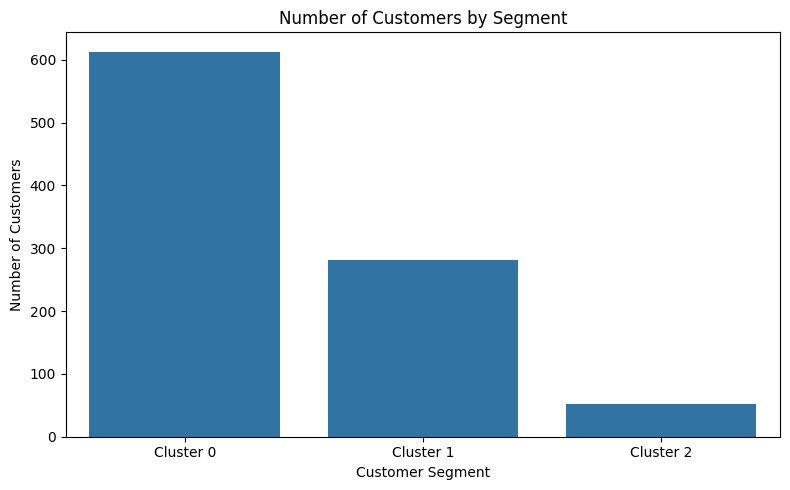

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customer_data,
    x="Customer_Segment"
)

plt.title("Number of Customers by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig(
    "customer_segment_summary.png",
    dpi=300
)

plt.show()

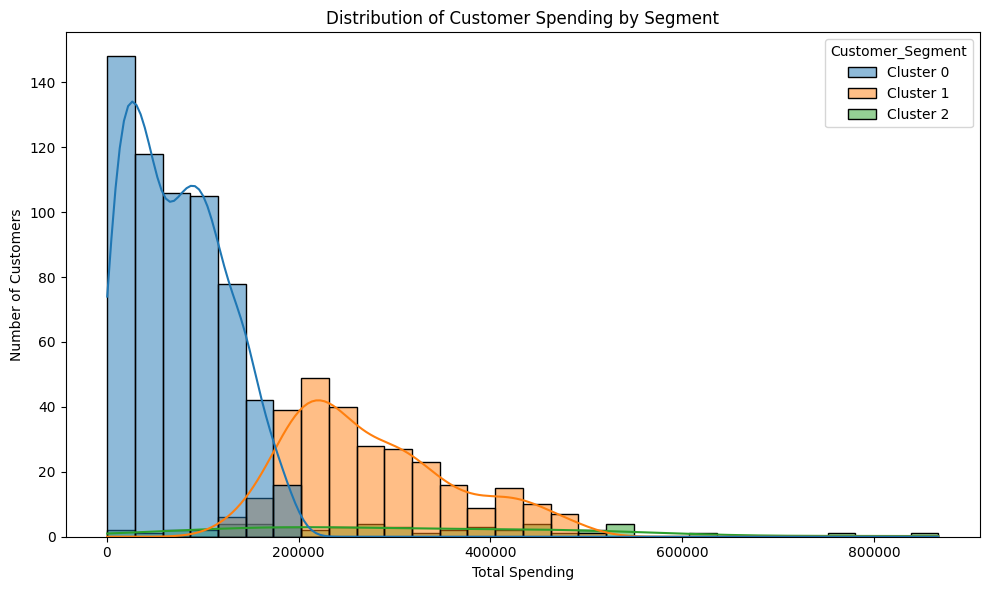

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=customer_data,
    x="Total_Spending",
    hue="Customer_Segment",
    kde=True,
    bins=30
)

plt.title("Distribution of Customer Spending by Segment")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig(
    "spending_distribution.png",
    dpi=300
)

plt.show()

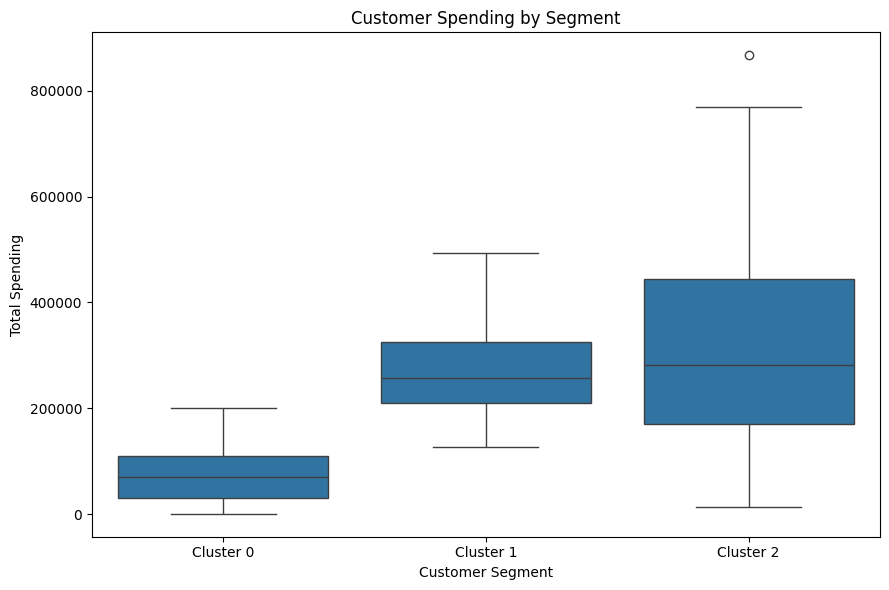

In [ ]:

plt.figure(figsize=(9,6))

sns.boxplot(
    data=customer_data,
    x="Customer_Segment",
    y="Total_Spending"
)

plt.title("Customer Spending by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.savefig(
    "spending_by_segment.png",
    dpi=300
)

plt.show()

In [ ]:
cluster0 = customer_data[
    customer_data["Customer_Segment"] == "Cluster 0"
]["Total_Spending"]

cluster1 = customer_data[
    customer_data["Customer_Segment"] == "Cluster 1"
]["Total_Spending"]

cluster2 = customer_data[
    customer_data["Customer_Segment"] == "Cluster 2"
]["Total_Spending"]

In [ ]:
levene_test = stats.levene(
    cluster0,
    cluster1,
    cluster2,
    center="median"
)

print("Levene Statistic:", levene_test.statistic)
print("p-value:", levene_test.pvalue)

Levene Statistic: 156.16322199446932
p-value: 2.57276873052657e-59


In [ ]:
kruskal_test = stats.kruskal(
    cluster0,
    cluster1,
    cluster2
)

print("Kruskal-Wallis Statistic:", kruskal_test.statistic)
print("p-value:", kruskal_test.pvalue)

Kruskal-Wallis Statistic: 600.521125623492
p-value: 3.967294477141263e-131


In [ ]:
segments = sorted(
    customer_data["Customer_Segment"].unique()
)

for segment_a, segment_b in combinations(segments, 2):

    group_a = customer_data[
        customer_data["Customer_Segment"] == segment_a
    ]["Total_Spending"]

    group_b = customer_data[
        customer_data["Customer_Segment"] == segment_b
    ]["Total_Spending"]

    result = stats.mannwhitneyu(
        group_a,
        group_b,
        alternative="two-sided"
    )

    print(
        segment_a,
        "vs",
        segment_b
    )

    print("U statistic:", result.statistic)
    print("p-value:", result.pvalue)
    print()

Cluster 0 vs Cluster 1
U statistic: 1117.0
p-value: 1.1784662968114723e-124

Cluster 0 vs Cluster 2
U statistic: 2779.0
p-value: 4.464471098161274e-23

Cluster 1 vs Cluster 2
U statistic: 6955.0
p-value: 0.5562326430441406



In [ ]:
def bootstrap_mean_difference(group_a, group_b, n_bootstrap=10000):

    rng = np.random.default_rng(42)

    differences = []

    for _ in range(n_bootstrap):

        sample_a = rng.choice(
            group_a,
            size=len(group_a),
            replace=True
        )

        sample_b = rng.choice(
            group_b,
            size=len(group_b),
            replace=True
        )

        differences.append(
            np.mean(sample_a) - np.mean(sample_b)
        )

    return np.percentile(
        differences,
        [2.5, 97.5]
    )

In [ ]:
for segment_a, segment_b in combinations(segments, 2):

    group_a = customer_data[
        customer_data["Customer_Segment"] == segment_a
    ]["Total_Spending"].values

    group_b = customer_data[
        customer_data["Customer_Segment"] == segment_b
    ]["Total_Spending"].values

    ci = bootstrap_mean_difference(
        group_a,
        group_b
    )

    mean_difference = (
        np.mean(group_a) -
        np.mean(group_b)
    )

    print(
        segment_a,
        "vs",
        segment_b
    )

    print("Mean difference:", mean_difference)
    print("95% CI:", ci)
    print()

Cluster 0 vs Cluster 1
Mean difference: -201889.20327091502
95% CI: [-212687.8480329  -191199.90744122]

Cluster 0 vs Cluster 2
Mean difference: -236964.38490212068
95% CI: [-288390.59315271 -187115.55267298]

Cluster 1 vs Cluster 2
Mean difference: -35075.18163120566
95% CI: [-86681.72160611  15046.68040917]



In [ ]:
results = pd.DataFrame({
    "Test": [
        "Kruskal-Wallis"
    ],
    "Statistic": [
        kruskal_test.statistic
    ],
    "p_value": [
        kruskal_test.pvalue
    ],
    "Alpha": [
        0.05
    ],
    "Decision": [
        "Reject H0"
    ]
})

results

,Test,Statistic,p_value,Alpha,Decision
0,Kruskal-Wallis,600.521126,3.967294e-131,0.05,Reject H0


In [ ]:
results.to_excel(
    "Task4_Statistical_Results.xlsx",
    index=False
)

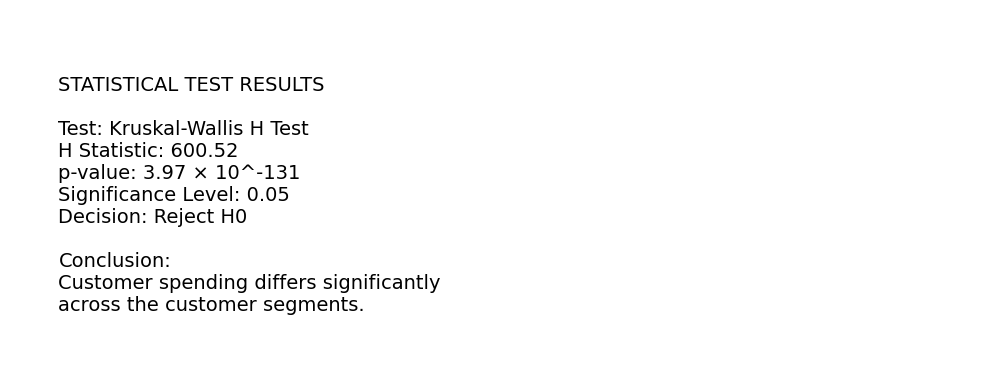

In [ ]:
plt.figure(figsize=(10,4))

plt.axis("off")

text = """
STATISTICAL TEST RESULTS

Test: Kruskal-Wallis H Test
H Statistic: 600.52
p-value: 3.97 × 10^-131
Significance Level: 0.05
Decision: Reject H0

Conclusion:
Customer spending differs significantly
across the customer segments.
"""

plt.text(
    0.05,
    0.5,
    text,
    fontsize=14,
    verticalalignment="center"
)

plt.tight_layout()
plt.savefig(
    "statistical_results.png",
    dpi=300
)

plt.show()